In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mri = pd.read_csv('mri_reports.csv', engine='python', on_bad_lines='skip')
eeg = pd.read_csv('eeg_reports.csv', engine='python', on_bad_lines='skip')

print('=== MRI ===')
print(f'Rows: {len(mri):,} | Unique patients: {mri["bdsp_patient_id"].nunique():,} | Unique sessions: {mri["session_id"].nunique():,}')

print('=== EEG ===')
print(f'Rows: {len(eeg):,} | Unique patients: {eeg["BDSPPatientID"].nunique():,} | Unique sessions: {eeg["SessionID"].nunique():,}')

=== MRI ===
Rows: 41,500 | Unique patients: 16,377 | Unique sessions: 41,496
=== EEG ===
Rows: 31,996 | Unique patients: 10,534 | Unique sessions: 172


## 1. MRI findings data quality and usable rows

In [ ]:
mri.head()

,bdsp_patient_id,session_id,Report_txt,Type,findings_unredacted,findings
0,114225914,156358,TECHNIQUE: MRI BRAIN WITH AND WITHOUT CONTRAST...,MRI BRAIN,There is a right transfrontal ventriculostomy ...,There is a right transfrontal ventriculostomy ...
1,114225914,156360,This study is for PACS storage only and not fo...,MRI BRAIN OUTSIDE (NO INTERPRETATION),not available,not available
2,114712316,200338,Reason for exam (per ***** order): *****Neuro ...,MRI BRAIN,Brain Parenchyma: There is redemonstration of ...,Brain Parenchyma: There is redemonstration of ...
3,114712316,202859,MRI BRAIN WITH AND WITHOUT CONTRAST *****/****...,MRI BRAIN,"BRAIN:\n \nParenchyma: No acute hemorrhage, in...","BRAIN:\n \nParenchyma: No acute hemorrhage, in..."
4,114712316,236988,MRI BRAIN WITH AND WITHOUT CONTRAST *****/****...,MRI ANGIO BRAIN,"BRAIN:\n \nParenchyma: No acute hemorrhage, in...","BRAIN:\n \nParenchyma: No acute hemorrhage, in..."


In [ ]:
# Separate usable rows (have actual findings text) from stubs
mri_valid = mri[
    mri['findings'].notna() &
    ~mri['findings'].str.strip().str.lower().isin(['not available', 'none', ''])
].copy()

mri_stub = mri[~mri.index.isin(mri_valid.index)]

print(f'Total rows:      {len(mri):,}')
print(f'Usable rows:     {len(mri_valid):,} ({100*len(mri_valid)/len(mri):.1f}%)')
print(f'Stub/empty rows: {len(mri_stub):,} ({100*len(mri_stub)/len(mri):.1f}%)')
print()

# Scan type breakdown for usable rows
print('Scan type breakdown (usable rows):')
print(mri_valid['Type'].value_counts().head(10).to_string())

Total rows:      41,500
Usable rows:     39,138 (94.3%)
Stub/empty rows: 2,362 (5.7%)

Scan type breakdown (usable rows):
Type
MRI BRAIN                                           34754
MRI BRAIN WITH AND WITHOUT CONTRAST                  1847
MRI ANGIO BRAIN                                      1100
MRI BRAIN WITHOUT CONTRAST                            323
NM PET BRAIN SEIZURES                                 222
MRI BRAIN FUNCTIONAL                                  178
NM PET BRAIN ALZHEIMER DEMENTIA                       168
MRI BRAIN OUTSIDE WITH INTERPRETATION OR CONSULT      102
MRA HEAD WITHOUT CONTRAST                              66
MRI BRAIN INTRAOP                                      59


## 2. MRI — longitudinal structure (multiple sessions per patient)

Sessions per patient:
  1 session:   9,268 patients
  2-5:         5,520 patients
  6+:          1,589 patients
  Max:         50 sessions (one patient)
  Mean:        2.53

=> Longitudinal data available. Parser should tag each finding with session ID
   to enable disease-progression overlays in the teaching tool.


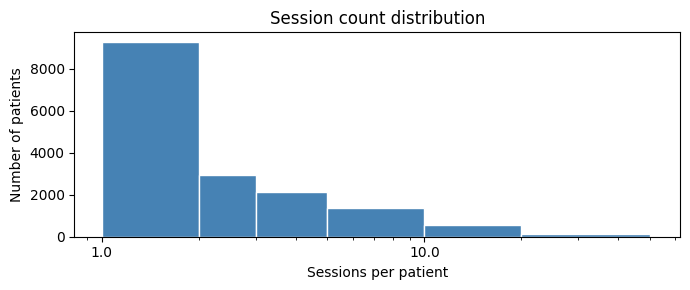

In [ ]:
sessions_per_patient = mri.groupby('bdsp_patient_id')['session_id'].count()

print('Sessions per patient:')
print(f'  1 session:   {(sessions_per_patient == 1).sum():,} patients')
print(f'  2-5:         {((sessions_per_patient >= 2) & (sessions_per_patient <= 5)).sum():,} patients')
print(f'  6+:          {(sessions_per_patient >= 6).sum():,} patients')
print(f'  Max:         {sessions_per_patient.max()} sessions (one patient)')
print(f'  Mean:        {sessions_per_patient.mean():.2f}')
print()
print('=> Longitudinal data available. Parser should tag each finding with session ID')
print('   to enable disease-progression overlays in the teaching tool.')

fig, ax = plt.subplots(figsize=(7, 3))
bins = [1, 2, 3, 5, 10, 20, 50, sessions_per_patient.max()+1]
ax.hist(sessions_per_patient, bins=bins, edgecolor='white', color='steelblue')
ax.set_xlabel('Sessions per patient')
ax.set_ylabel('Number of patients')
ax.set_title('Session count distribution')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

## 3. MRI — findings text length (why we need a splitter)

Structural MRI rows: 36,924

Findings text length (chars):
count    36924.0
mean      1557.0
std        935.0
min          5.0
25%        910.0
50%       1359.0
75%       1968.0
max      13184.0

=> Median ~1,300 chars. Max >22,000. Reports are not single-finding —
   the parser must split each report into individual findings before extraction.


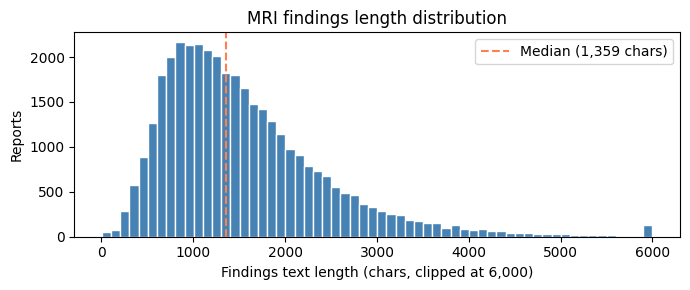

In [ ]:
# Focus on structural MRI (most relevant for VoxelPrompt)
structural = mri_valid[mri_valid['Type'].isin([
    'MRI BRAIN',
    'MRI BRAIN WITH AND WITHOUT CONTRAST',
    'MRI BRAIN WITHOUT CONTRAST'
])].copy()

structural['findings_len'] = structural['findings'].str.len()

print(f'Structural MRI rows: {len(structural):,}')
print()
print('Findings text length (chars):')
print(structural['findings_len'].describe().round(0).to_string())
print()
print('=> Median ~1,300 chars. Max >22,000. Reports are not single-finding —')
print('   the parser must split each report into individual findings before extraction.')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(structural['findings_len'].clip(upper=6000), bins=60, edgecolor='white', color='steelblue')
ax.axvline(structural['findings_len'].median(), color='coral', linestyle='--', label=f'Median ({int(structural["findings_len"].median()):,} chars)')
ax.set_xlabel('Findings text length (chars, clipped at 6,000)')
ax.set_ylabel('Reports')
ax.set_title('MRI findings length distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 4. MRI — pathology keyword prevalence

Note: keyword hits include negations (e.g. "no acute infarct").
These represent mentions, not confirmed diagnoses.

                      count  pct_of_reports
Edema                  5129       13.890694
Atrophy                5225       14.150688
Tumor / metastasis    10994       29.774672
Midline shift         12355       33.460622
Hydrocephalus         15866       42.969342
White matter disease  17375       47.056115
Hemorrhage            25274       68.448705
Infarct / stroke      26844       72.700682

=> Dataset covers major pathology categories. Good coverage for a teaching tool.


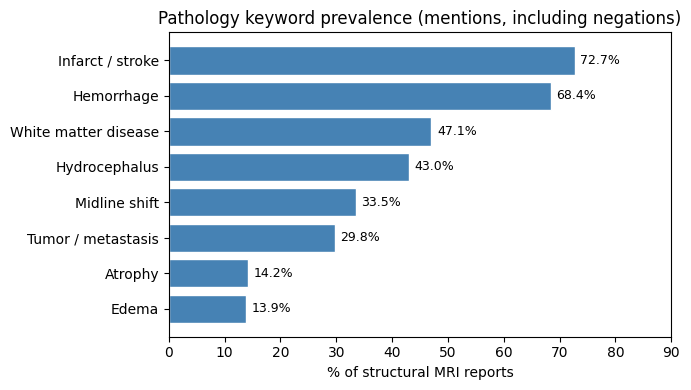

In [ ]:
import re

keywords = {
    'Infarct / stroke':      r'infarct|ischemi|stroke',
    'Hemorrhage':            r'hemorrhage|hematoma',
    'White matter disease':  r'white matter|leukoencephalop|demyelinat',
    'Hydrocephalus':         r'hydrocephalus',
    'Midline shift':         r'midline shift',
    'Tumor / metastasis':    r'tumor|metasta|neoplasm|glioma|glioblastoma',
    'Edema':                 r'edema',
    'Atrophy':               r'atrophy|volume loss',
}

counts = {
    label: structural['findings'].str.lower().str.contains(pattern, regex=True, na=False).sum()
    for label, pattern in keywords.items()
}
counts_pct = {k: 100 * v / len(structural) for k, v in counts.items()}
kw_df = pd.DataFrame({'count': counts, 'pct': counts_pct}).sort_values('pct', ascending=True)

print('Note: keyword hits include negations (e.g. "no acute infarct").')
print('These represent mentions, not confirmed diagnoses.\n')
print(kw_df[['count', 'pct']].rename(columns={'pct': 'pct_of_reports'}).to_string())
print()
print('=> Dataset covers major pathology categories. Good coverage for a teaching tool.')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(kw_df.index, kw_df['pct'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('% of structural MRI reports')
ax.set_title('Pathology keyword prevalence (mentions, including negations)')
ax.set_xlim(0, 90)
plt.tight_layout()
plt.show()

## 5. MRI — multi-finding reports (motivates per-finding extraction)

Sample paragraph counts:
paragraph_count
1      306
2      999
3     1207
4     2954
5     2817
6     2846
7     5063
8     4276
9     3675
10    2941
11    2365
12    1639
13    1197
14     860
15     615

Reports with >1 paragraph: 36,618 (99.2%)


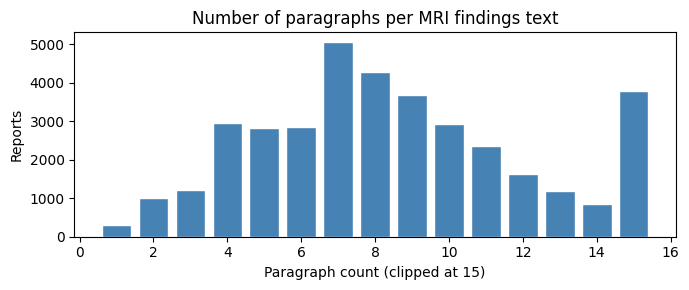

In [ ]:
def count_findings(text):
    if pd.isna(text):
        return 0
    paragraphs = [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]
    return max(1, len(paragraphs))

structural['paragraph_count'] = structural['findings'].apply(count_findings)

# Sanity check
print('Sample paragraph counts:')
print(structural['paragraph_count'].value_counts().sort_index().head(15).to_string())
print()
print(f'Reports with >1 paragraph: {(structural["paragraph_count"] > 1).sum():,} ({100*(structural["paragraph_count"] > 1).mean():.1f}%)')

fig, ax = plt.subplots(figsize=(7, 3))
vc = structural['paragraph_count'].clip(upper=15).value_counts().sort_index()
ax.bar(vc.index.astype(int), vc.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Paragraph count (clipped at 15)')
ax.set_ylabel('Reports')
ax.set_title('Number of paragraphs per MRI findings text')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [ ]:
import random
import re
import pandas as pd

def split_findings(text):
    if pd.isna(text):
        return []
    return [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]

# Sample 10 reports across the length distribution
short = structural.nsmallest(500, 'findings_len').sample(3, random_state=42)
medium = structural[
    structural['findings_len'].between(1200, 1500)
].sample(4, random_state=42)
long_df = structural.nlargest(500, 'findings_len').sample(3, random_state=42)

sample = pd.concat([short, medium, long_df]).reset_index(drop=True)

for i, row in sample.iterrows():
    paragraphs = split_findings(row['findings'])
    print(f"{'='*60}")
    print(f"Report {i+1} | Type: {row['Type']} | Total chars: {row['findings_len']} | Paragraphs detected: {len(paragraphs)}")
    print(f"{'='*60}")
    for j, p in enumerate(paragraphs):
        print(f"\n--- Paragraph {j+1} ---")
        print(p[:300] + ('...' if len(p) > 300 else ''))
    print()

Report 1 | Type: MRI BRAIN | Total chars: 292 | Paragraphs detected: 3

--- Paragraph 1 ---
Nondiagnostic examination.

--- Paragraph 2 ---
The patient may return for a repeat MRI study when the patient is able to
tolerate the examination.

--- Paragraph 3 ---
This report has been forwarded to an automated communication system which will
electronically notify appropriate providers of potentially important findings.

Report 2 | Type: MRI BRAIN | Total chars: 147 | Paragraphs detected: 2

--- Paragraph 1 ---
Study aborted at patient request. Only localizer sequences obtained. No obvious gross abnormality.

--- Paragraph 2 ---
Aborted study. No obvious gross abnormality.

Report 3 | Type: MRI BRAIN | Total chars: 295 | Paragraphs detected: 2

--- Paragraph 1 ---
Patient status post left frontal craniotomy with postop
changes and gliosis of the left frontal lobe. Ventricle size
stable. There is been no interval change. Left maxillary sinus
retention cysts again seen. After contrast no abno

In [ ]:
import pandas as pd
import re

# ── 1. Load ───────────────────────────────────────────────────────────────────

mri = pd.read_csv('mri_reports.csv', engine='python', on_bad_lines='skip')

mri_valid = mri[
    mri['findings'].notna() &
    ~mri['findings'].str.strip().str.lower().isin(['not available', 'none', ''])
].copy()

structural = mri_valid[mri_valid['Type'].isin([
    'MRI BRAIN',
    'MRI BRAIN WITH AND WITHOUT CONTRAST',
    'MRI BRAIN WITHOUT CONTRAST'
])].copy()

print(f'Structural MRI rows loaded: {len(structural):,}')


# ── 2. Split into paragraphs ──────────────────────────────────────────────────

def split_findings(text):
    if pd.isna(text):
        return []
    return [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]

structural['paragraph_list'] = structural['findings'].apply(split_findings)
exploded = (
    structural
    .explode('paragraph_list')
    .rename(columns={'paragraph_list': 'paragraph'})
    .dropna(subset=['paragraph'])
    .reset_index(drop=True)
)

print(f'Total paragraphs after split: {len(exploded):,}')


# ── 3. Filter noise ───────────────────────────────────────────────────────────

# 3a. Too short to be a real finding (headers, stubs, lone punctuation)
MIN_LENGTH = 30
mask_short = exploded['paragraph'].str.len() < MIN_LENGTH

# 3b. Section headers (standalone labels with no sentence content)
HEADER_PATTERN = re.compile(
    r'^(brain mri|head mra|neck mra|mri brain|intracranial mra'
    r'|anterior circulation|posterior circulation|collateral circulation'
    r'|aortic\s+\[redacted\].*origin of major cervical'
    r'|impression|technique|comparison|indication|methodology'
    r'|detail|findings|neck|skull base.*normal\.?):?\s*$',
    re.IGNORECASE
)
mask_header = exploded['paragraph'].str.match(HEADER_PATTERN, na=False)

# 3c. Administrative / boilerplate / technical notes
BOILERPLATE_PATTERN = re.compile(
    r'forwarded to an automated communication'
    r'|findings were (discussed|communicated)'
    r'|carotid stenosis reference'
    r'|i,? the (attending|teaching) physician'
    r'|alert notification of critical'
    r'|critical results were communicated'
    r'|this report has been'
    r'|electronically notify'
    r'|study (terminated|aborted|discontinued) (early|due to|at patient)',
    re.IGNORECASE
)
mask_boilerplate = exploded['paragraph'].str.contains(BOILERPLATE_PATTERN, na=False)

# 3d. Pure negative / normal findings (nothing to highlight in VXP)
#     Tag these rather than drop -- useful for the teaching tool as ground truth
NEGATIVE_PATTERN = re.compile(
    r'^(there is |there are )?(no evidence of|no acute|no new|no abnormal'
    r'|no significant|unremarkable|within normal limits|no hemorrhage'
    r'|no infarct|no mass effect|no hydrocephalus|no midline shift'
    r'|patent|intact|clear|stable and unremarkable)'
    r'|^the (major |main )?(intracranial )?(flow voids|arterial flow voids|vessels).{0,60}(intact|preserved|patent)'
    r'|^(extracranial structures|paranasal sinuses|mastoid|orbits).{0,80}(clear|normal|unremarkable)',
    re.IGNORECASE
)
exploded['is_negative'] = exploded['paragraph'].str.match(NEGATIVE_PATTERN, na=False)

# 3e. Extracranial / non-brain paragraphs -- flag separately, not useful for VXP brain overlays
EXTRACRANIAL_PATTERN = re.compile(
    r'^(paranasal sinuses|mastoid air cells|orbits|skull base'
    r'|extracranial soft tissues|cervical|vertebral arter'
    r'|aortic|subclavian|carotid)',
    re.IGNORECASE
)
exploded['is_extracranial'] = exploded['paragraph'].str.match(EXTRACRANIAL_PATTERN, na=False)

# Apply hard filters
noise_mask = mask_short | mask_header | mask_boilerplate
filtered = exploded[~noise_mask].copy().reset_index(drop=True)

print(f'Paragraphs removed (noise): {noise_mask.sum():,}')
print(f'  - Too short (<{MIN_LENGTH} chars): {mask_short.sum():,}')
print(f'  - Section headers:                {mask_header.sum():,}')
print(f'  - Boilerplate/admin:              {mask_boilerplate.sum():,}')
print(f'Paragraphs remaining:              {len(filtered):,}')
print(f'  - Tagged negative/normal:         {filtered["is_negative"].sum():,}')
print(f'  - Tagged extracranial:            {filtered["is_extracranial"].sum():,}')
print(f'  - Positive brain findings:        {(~filtered["is_negative"] & ~filtered["is_extracranial"]).sum():,}')


# ── 4. Spot-check ─────────────────────────────────────────────────────────────

print('\n=== 5 sample POSITIVE findings ===')
sample_pos = filtered[~filtered['is_negative']]['paragraph'].sample(5, random_state=42)
for p in sample_pos:
    print(f'  - {p[:150]}')
    print()

print('=== 5 sample NEGATIVE findings (tagged, not dropped) ===')
sample_neg = filtered[filtered['is_negative']]['paragraph'].sample(5, random_state=42)
for p in sample_neg:
    print(f'  - {p[:150]}')
    print()


# ── 5. Save ───────────────────────────────────────────────────────────────────

out_cols = ['bdsp_patient_id', 'session_id', 'Type', 'paragraph', 'is_negative', 'is_extracranial']
filtered[out_cols].to_csv('mri_findings_split.csv', index=False)
print('Saved: mri_findings_split.csv')

Structural MRI rows loaded: 36,924
Total paragraphs after split: 334,062


/tmp/ipykernel_18634/2852898542.py:71: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_boilerplate = exploded['paragraph'].str.contains(BOILERPLATE_PATTERN, na=False)


Paragraphs removed (noise): 35,903
  - Too short (<30 chars): 23,366
  - Section headers:                11,071
  - Boilerplate/admin:              8,032
Paragraphs remaining:              298,159
  - Tagged negative/normal:         48,461
  - Tagged extracranial:            10,195
  - Positive brain findings:        243,146

=== 5 sample POSITIVE findings ===
  - The nodular enhancement at the posterior body of the left lateral ventricle,
measuring up to 12 mm is not significantly changed in size when compared 

  - Image quality is degraded by artifact related to patient motion.

  - Redemonstration of innumerable punctate foci of susceptibility artifact involving the supratentorial brain predominantly in a peripheral distribution.

  - Tiny subcortical T2 hyperintensity within the right superior frontal gyrus. This is a nonspecific finding, though may represent a small focal cortical

  - The extracranial structures are unchanged.

=== 5 sample NEGATIVE findings (tagged, not dropped

In [ ]:
import pandas as pd
import random

df = pd.read_csv('/content/mri_findings_split.csv')

# Sample across short, medium, long paragraphs
df['para_len'] = df['paragraph'].str.len()

short = df[df['para_len'] < 100].sample(10, random_state=42)
medium = df[df['para_len'].between(100, 300)].sample(10, random_state=42)
long = df[df['para_len'] > 300].sample(10, random_state=42)

for label, sample in [('SHORT', short), ('MEDIUM', medium), ('LONG', long)]:
    print(f'\n=== {label} ===')
    for _, row in sample.iterrows():
        print(f"[{'NEG' if row['is_negative'] else 'POS'}] {row['paragraph']}")
        print()


=== SHORT ===
[NEG] No evidence of an enhancing lesion.

[POS] The cervical segments of the dominant left vertebral arteries appear normal.

[NEG] There is no evidence of hemorrhage or acute infarction.

[POS] Skull Base, [REDACTED], and Visualized Upper Cervical Spine: Normal.

[POS] The major intracranial flow voids appear preserved.

[POS] There is scattered fluid in the bilateral mastoid air cells.

[POS] There are no additional areas of parenchymal, subpleural ependymal, or meningeal
enhancement.

[POS] The flow voids of the major intracranial vessels appear intact.

[POS] AORTIC [REDACTED] AND ORIGIN OF MAJOR CERVICAL VESSELS

[POS] The major intracranial arterial flow voids are intact.


=== MEDIUM ===
[NEG] There is no new or increasing enhancement associated with the left precentral
gyrus operative site. The surrounding T2/FLAIR hyperintensity appears unchanged.

[POS] Study terminated early due to patient discomfort, with only diffusion and
sagittal T1 sequences performed.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/mri_findings_split.csv', '/content/drive/MyDrive/mri_findings_split.csv')

Mounted at /content/drive


'/content/drive/MyDrive/mri_findings_split.csv'

## 6. EEG — service type breakdown and structural difference from MRI

EEG service types:
ServiceName
LTM         26722
Routine     15712
EMU          6800
Faulkner      542
OR             51
Fish           19

=> Three structurally different note formats:
   Routine  — short, single session, outpatient-style
   LTM      — multi-epoch, timestamped, inpatient (most complex)
   EMU      — epilepsy monitoring unit, pre-surgical

=> EEG parser needs subtype routing before extraction.
   MRI parser is simpler — build that first.


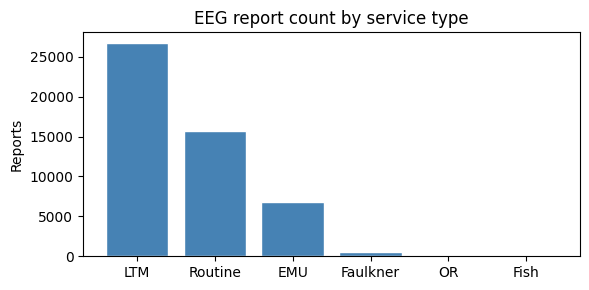

In [ ]:
print('EEG service types:')
print(eeg['ServiceName'].value_counts().to_string())
print()
print('=> Three structurally different note formats:')
print('   Routine  — short, single session, outpatient-style')
print('   LTM      — multi-epoch, timestamped, inpatient (most complex)')
print('   EMU      — epilepsy monitoring unit, pre-surgical')
print()
print('=> EEG parser needs subtype routing before extraction.')
print('   MRI parser is simpler — build that first.')

fig, ax = plt.subplots(figsize=(6, 3))
vc = eeg['ServiceName'].value_counts()
ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
ax.set_ylabel('Reports')
ax.set_title('EEG report count by service type')
plt.tight_layout()
plt.show()

## 7. redacted vs unredacted — confirm which column to use

In [ ]:
# Both columns are PHI-scrubbed — only the redaction format differs
diff_mask = mri['findings_unredacted'].fillna('') != mri['findings'].fillna('')
print(f'Rows where findings vs findings_unredacted differ: {diff_mask.sum():,}')
print()

# Show a side-by-side of the difference
sample = mri[diff_mask].iloc[0]
u = sample['findings_unredacted']
r = sample['findings']
for j, (a, b) in enumerate(zip(u, r)):
    if a != b:
        print('findings_unredacted (around first diff):')
        print(repr(u[max(0,j-20):j+50]))
        print()
        print('findings (around first diff):')
        print(repr(r[max(0,j-20):j+50]))
        break

print()
print('=> Both columns are PHI-scrubbed. findings_unredacted uses ***** masking,')
print('   findings uses [REDACTED] / [DATE] tags.')
print('   Use `findings` — tags are explicit and easier to handle downstream.')

Rows where findings vs findings_unredacted differ: 30,269

findings_unredacted (around first diff):
'iled below (axial\n \n***** Increase in size of the dominant supratentor'

findings (around first diff):
'iled below (axial\n \n[REDACTED] Increase in size of the dominant suprat'

=> Both columns are PHI-scrubbed. findings_unredacted uses ***** masking,
   findings uses [REDACTED] / [DATE] tags.
   Use `findings` — tags are explicit and easier to handle downstream.
